In [1]:
import string
from random import random

import matplotlib.pyplot as plt
import torch
from models import *

data = open('names.txt', 'r').read().splitlines(keepends=False)
print(data[:5])

['emma', 'olivia', 'ava', 'isabella', 'sophia']


In [ ]:
bigram = Bigram()
bigram.fit(data)

In [3]:
bigram.make(5)

['kyason.', 'kanana.', 'milaveela.', 'ra.', 'drisan.']

In [4]:
bigram.loss(data)

2.4543561935424805

In [2]:
generator = torch.Generator().manual_seed(1234)
nn = NN(generator=generator)

nn.fit(data)

Loss=2.4627


In [3]:
generator = torch.Generator().manual_seed(1234)
nn.make(generator=generator)

['kyason.', 'kanana.', 'milaveela.', 'ra.', 'drisan.']

In [2]:
stoi = {s: i+1 for i, s in enumerate(string.ascii_lowercase)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}

In [3]:
context_size = 8

def build_datasets(data):
    X, Y = [], []
    for word in data:
        context = [0] * context_size
        for char in word + '.':
            idx = stoi[char]
            X.append(context)
            Y.append(idx)
            context = context[1:] + [idx]

    return torch.tensor(X), torch.tensor(Y)

import random
random.seed(42)
random.shuffle(data)

n1 = int(len(data) * 0.8)
n2 = int(len(data) * 0.9)

Xtrain, ytrain = build_datasets(data[:n1])
Xdev, ydev = build_datasets(data[n1:n2])
Xtest, ytest = build_datasets(data[n2:])

In [4]:
vocab_size = len(stoi) # 27
n_embed = 24
n_hidden = 128

g = torch.Generator().manual_seed(2147483647)

model = Sequential([
    Embedding(vocab_size, n_embed),
    FlattenConsecutive(2), Linear(n_embed * 2, n_hidden, generator=g, gain = 5./3., bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, generator=g, gain = 5./3., bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, generator=g, gain = 5./3., bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size, generator=g, gain = 5./3., bias=False)
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum([p.nelement() for p in parameters]))

for p in parameters:
    p.requires_grad = True

76552


In [5]:
n_epochs = 100_000
batch_size = 32
ud = []
lossi = []

for epoch in range(n_epochs):
    # get batch
    idx = torch.randint(0, Xtrain.shape[0], (batch_size, ))
    x, y = Xtrain[idx], ytrain[idx]

    # forward pass
    logits = model(x)
    loss = F.cross_entropy(logits, y)

    # backward pass
    for layer in model.layers:
        layer.out.retain_grad()

    for p in parameters:
        p.grad = None

    loss.backward()

    # update
    lr = 0.1 if epoch < n_epochs / 2 else 0.05
    for p in parameters:
        p.data += -lr * p.grad

    if epoch % 10000 == 0:
        print(f'{epoch}/{n_epochs} {loss:.4f}')

    with torch.no_grad():
        ud.append([((lr * p.grad).std() / p.data.std()).log10().item() for p in parameters])
        lossi.append(loss.log10().item())

loss

0/100000 3.3010
10000/100000 1.8186
20000/100000 2.3311
30000/100000 2.0788
40000/100000 2.0550
50000/100000 2.1138
60000/100000 2.1707
70000/100000 1.6103
80000/100000 1.4822
90000/100000 2.0537


tensor(2.1814, grad_fn=<NllLossBackward0>)

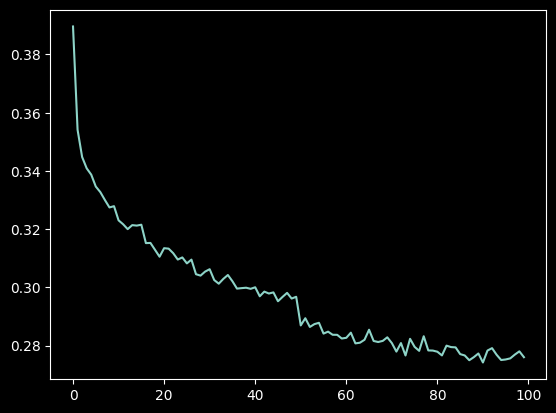

In [6]:
losses = torch.tensor(lossi).view((-1, 1000)).mean(1)
plt.plot(losses)

layer 4 (Tanh): mean: 0.01, std: 0.56, saturated: 13.15%
layer 8 (Tanh): mean: 0.01, std: 0.66, saturated: 17.85%
layer 12 (Tanh): mean: 0.03, std: 0.71, saturated: 11.28%


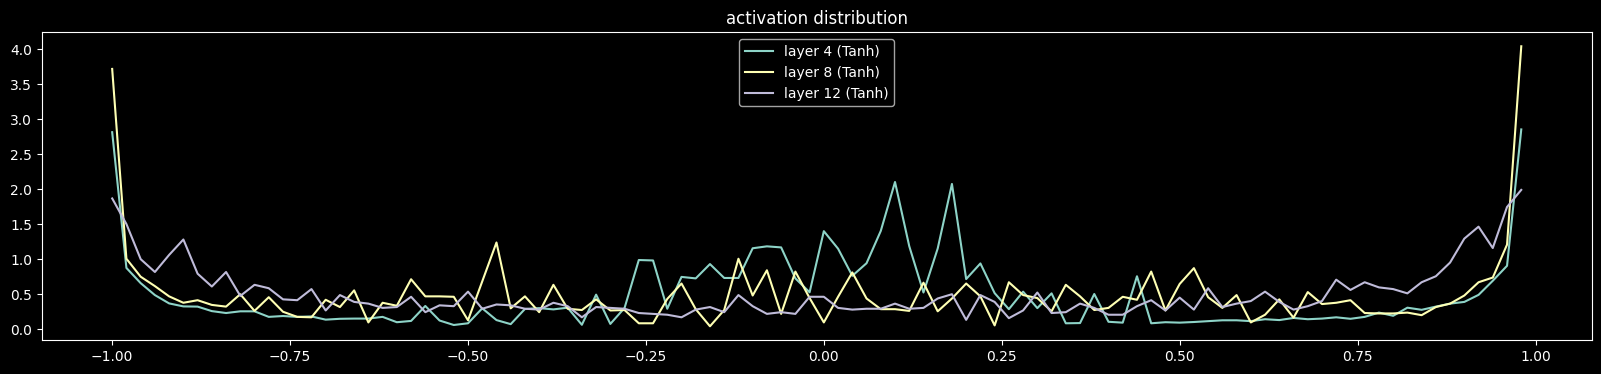

In [7]:
import histograms as H

H.activation_dist(model.layers)

Layer 4 (Tanh): mean -0.000000 std: 3.014891e-03
Layer 8 (Tanh): mean +0.000000 std: 3.323965e-03
Layer 12 (Tanh): mean -0.000092 std: 5.972496e-03


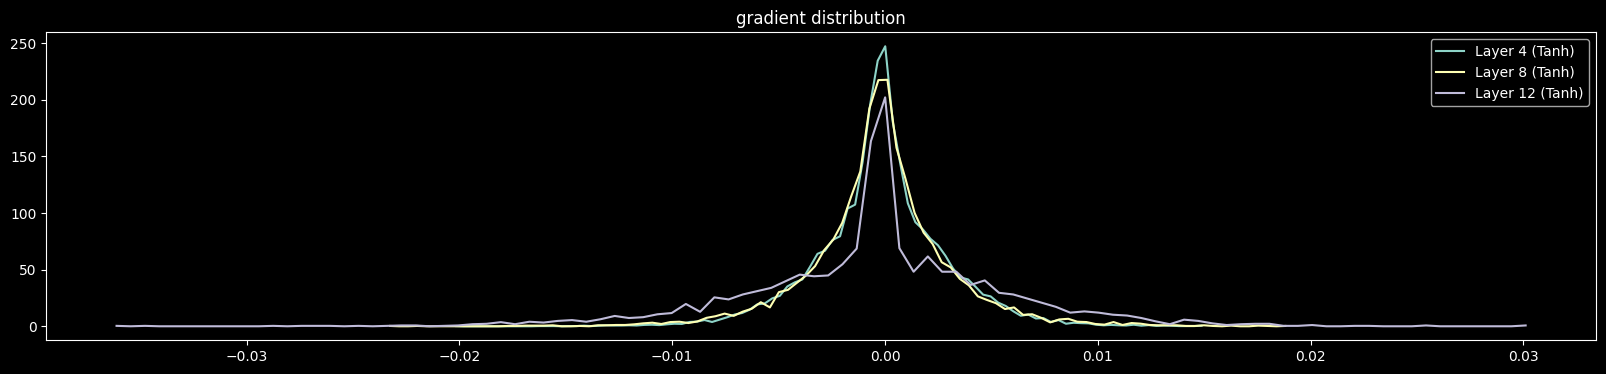

In [8]:
H.gradient_distribution(model.layers)

weight (27, 24) | mean: -0.000000 | std: 1.490879e-02 | grad:data ratio 1.434788e-02
weight (48, 128) | mean: +0.000198 | std: 8.964295e-03 | grad:data ratio 2.834227e-02
weight (256, 128) | mean: +0.000021 | std: 6.116237e-03 | grad:data ratio 3.572535e-02
weight (256, 128) | mean: -0.000028 | std: 5.779035e-03 | grad:data ratio 3.580743e-02
weight (128, 27) | mean: +0.000000 | std: 2.115608e-02 | grad:data ratio 9.332056e-02


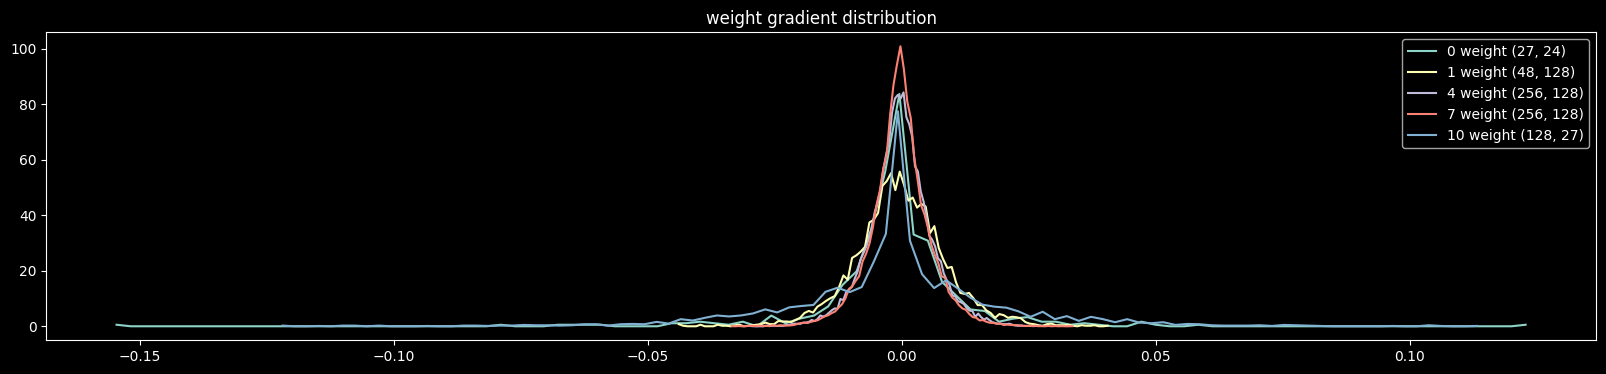

In [9]:
H.weight_gradient_dist(parameters)

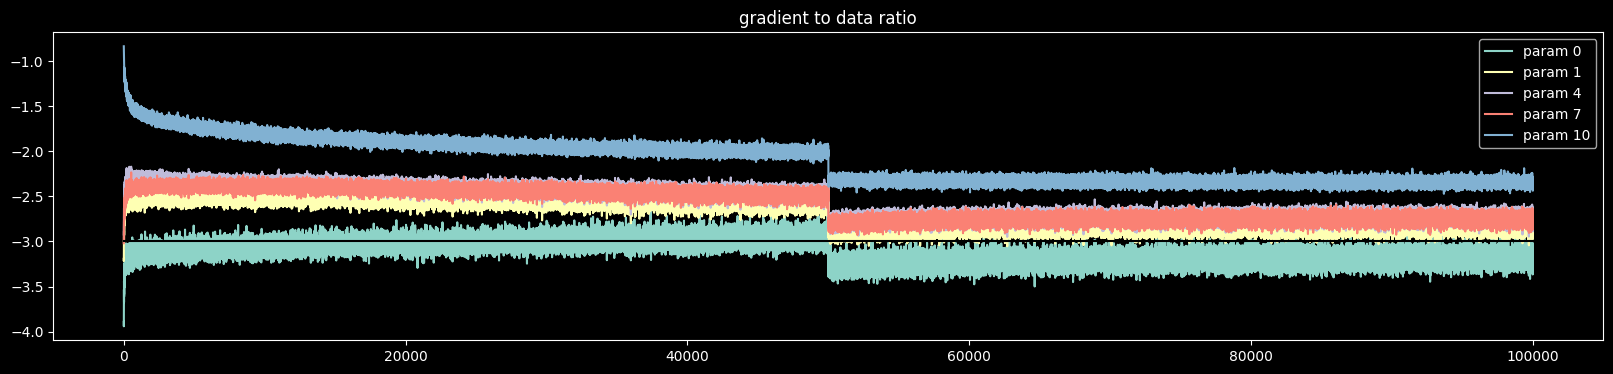

In [10]:
H.grad_data_ratio(parameters, ud)

In [11]:
for layer in model.layers:
    if isinstance(layer, BatchNorm1d):
        layer.training = False

with torch.no_grad():
    idx = torch.randint(0, Xdev.shape[0], (batch_size, ))
    x, y = Xdev[idx], ydev[idx]

    # forward pass
    logits = model(x)
    loss = F.cross_entropy(logits, y)

loss

tensor(2.3120)

In [12]:
g = torch.Generator().manual_seed(2147483647 + 10)

def generate(count = 20):
    for layer in model.layers:
        if isinstance(layer, BatchNorm1d):
            layer.training = False

    out = []
    for i in range(count):
        context = [0] * context_size
        res = []

        while True:
            x = torch.tensor([context])
            # forward pass
            logits = model(x)
            probs = F.softmax(logits, dim=1)
            pred = torch.multinomial(probs, 1, generator=g).item()

            res.append(pred)
            context = context[1:] + [pred]

            if pred == 0:
                break

        out.append(''.join(itos[i] for i in res))

    return out

generate()

['carpa.',
 'fatimi.',
 'kitzirle.',
 'reviyah.',
 'cassie.',
 'rahith.',
 'ameryn.',
 'jareti.',
 'nellari.',
 'chaily.',
 'kaleigh.',
 'hamserin.',
 'quint.',
 'saline.',
 'livani.',
 'wavell.',
 'dearis.',
 'kaileigh.',
 'sabie.',
 'decii.']